# Rn222 repetition comparison and depth detection

This notebook uses the generated simulations to compare Rn222 configurations against the baseline, including repetition-aware uncertainty, detector-panel profiles, and cumulative time cuts.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import display
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path

pd.set_option('display.max_colwidth', None)


## Shared configuration and helper functions

The functions in this section are used by the Y-panel, X-panel, and time-window analyses. They load completed repetitions from `generated_files_log.tsv`, filter detector entries, build normalized profiles/maps, and calculate residuals with combined uncertainty.


In [2]:
# Shared repetition-analysis configuration and helpers

repetition_run_dir = './rn222_repetition_runs/rn222_2mmfully_10reps_10k'
generated_files_log = f'{repetition_run_dir}/generated_files_log.tsv'
use_repetition_outputs = True
normalization = 'events'

analysis_cases = {
    'baseline': {'label': 'No diffusion baseline', 'path': './PhotonDetector/build/2mm_2mm_10k_photon_boundaries.csv'},
    'diff10': {'label': 'Source diffusion 10%', 'path': './PhotonDetector/build/2mm_2mm_10k_10diffRn222_photon_boundaries.csv'},
    'diff50': {'label': 'Source diffusion 50%', 'path': './PhotonDetector/build/2mm_2mm_10k_50diffRn222_photon_boundaries.csv'},
    'diff90': {'label': 'Source diffusion 90%', 'path': './PhotonDetector/build/2mm_2mm_10k_90diffRn222_photon_boundaries.csv'},
    'loc40': {'label': 'Source localized 40%', 'path': './PhotonDetector/build/2mm_2mm_10k_40_Rn222_loc_photon_boundaries.csv'},
    'loc60': {'label': 'Source localized 60%', 'path': './PhotonDetector/build/2mm_2mm_10k_60_Rn222_loc_photon_boundaries.csv'},
}

candidate_keys = ['diff10', 'diff50', 'diff90', 'loc40', 'loc60']
case_labels = {key: value['label'] for key, value in analysis_cases.items()}

y_panels = ['physPhotonDetectorPosY', 'physPhotonDetectorNegY']
x_panels = ['physPhotonDetectorPosX', 'physPhotonDetectorNegX']
all_detector_panels = y_panels + x_panels

z_bins = np.linspace(-1500, 1500, 60)
x_bins = np.linspace(-500, 500, 40)
depth_y_bins = np.linspace(-150, 150, 50)
depth_z_bins = np.linspace(-800, 800, 60)

time_thresholds = [
    ('1 h', 1 * 3600),
    ('2 h', 2 * 3600),
    ('12 h', 12 * 3600),
    ('1 d', 1 * 24 * 3600),
    ('2 d', 2 * 24 * 3600),
    ('5 d', 5 * 24 * 3600),
    ('10 d', 10 * 24 * 3600),
]

def output_csv_from_stem(output_stem):
    """Convert a simulation output prefix from the manifest into a photon boundary CSV path."""
    return f'{output_stem}_photon_boundaries.csv'

def load_repetition(path, case_key, rep):
    """Load one repetition and keep the columns needed by all profile, map, and time analyses."""
    usecols = ['eventID', 'particleName', 'boundary', 'volumeName', 'x_mm', 'y_mm', 'z_mm', 'time_s']
    df = pd.read_csv(path, usecols=usecols)
    entries = df[
        (df['particleName'] == 'gamma')
        & (df['boundary'] == 'enter')
        & (df['volumeName'].isin(all_detector_panels))
    ].copy()
    return {
        'case': case_key,
        'rep': rep,
        'path': str(path),
        'entries': entries,
        'n_events': df['eventID'].nunique(),
    }

def load_repetition_cases():
    """Load completed repetitions from generated_files_log.tsv, or fall back to legacy single-run CSVs."""
    log_path = Path(generated_files_log)
    if use_repetition_outputs and log_path.exists():
        log_df = pd.read_csv(log_path, sep='	')
        reps_by_case = {key: [] for key in analysis_cases}
        skipped = []
        for row in log_df.itertuples(index=False):
            csv_path = Path(output_csv_from_stem(row.output_stem))
            if not csv_path.exists():
                skipped.append({'case': row.case, 'rep': row.rep, 'expected_csv': str(csv_path)})
                continue
            reps_by_case[row.case].append(load_repetition(csv_path, row.case, row.rep))
        return {case: reps for case, reps in reps_by_case.items() if reps}, pd.DataFrame(skipped)

    cases = {
        key: [load_repetition(value['path'], key, 1)]
        for key, value in analysis_cases.items()
        if Path(value['path']).exists()
    }
    return cases, pd.DataFrame()

def print_repetition_summary(cases, skipped_df, label='Available repetitions'):
    """Print the loaded repetition numbers and show any expected CSVs that are still missing."""
    print(f'{label}:')
    for key in sorted(cases):
        reps = [rep['rep'] for rep in cases[key]]
        n_entries = sum(len(rep['entries']) for rep in cases[key])
        print(f"  {key}: {len(reps)} reps {reps}, {n_entries} detector entries")
    if not skipped_df.empty:
        print(f"Skipped missing outputs: {len(skipped_df)}")
        display(skipped_df.head(10))

def select_entries(rep, panels, time_limit_s=None):
    """Select detector entries for the requested panels, optionally applying cumulative time_s <= limit."""
    entries = rep['entries']
    selected = entries[entries['volumeName'].isin(panels)]
    if time_limit_s is not None:
        selected = selected[selected['time_s'].notna() & (selected['time_s'] <= time_limit_s)]
    return selected

def profile_counts(rep, panels, value_col, bins, time_limit_s=None):
    """Histogram one detector coordinate for a repetition after panel and optional time cuts."""
    selected = select_entries(rep, panels, time_limit_s=time_limit_s)
    return np.histogram(selected[value_col], bins=bins)[0].astype(float)

def map_counts(rep, panels, x_col, y_col, x_bins_for_map, y_bins_for_map, time_limit_s=None):
    """Build one 2D detector hit map for a repetition after panel and optional time cuts."""
    selected = select_entries(rep, panels, time_limit_s=time_limit_s)
    hist, x_edges, y_edges = np.histogram2d(selected[x_col], selected[y_col], bins=[x_bins_for_map, y_bins_for_map])
    return hist.astype(float), x_edges, y_edges

def stack_profile_counts(repetitions, panels, value_col, bins, time_limit_s=None):
    """Stack one 1D histogram per repetition."""
    return np.vstack([profile_counts(rep, panels, value_col, bins, time_limit_s=time_limit_s) for rep in repetitions])

def stack_map_counts(repetitions, panels, x_col, y_col, x_bins_for_map, y_bins_for_map, time_limit_s=None):
    """Stack one 2D histogram per repetition."""
    hists = []
    x_edges = y_edges = None
    for rep in repetitions:
        hist, x_edges, y_edges = map_counts(rep, panels, x_col, y_col, x_bins_for_map, y_bins_for_map, time_limit_s=time_limit_s)
        hists.append(hist)
    return np.stack(hists), x_edges, y_edges

def repetition_events(repetitions):
    """Return generated-event counts for event-normalized rates."""
    return np.array([rep['n_events'] for rep in repetitions], dtype=float)

def mean_sem_from_counts(counts, events, fallback='poisson'):
    """Normalize counts per event and return mean plus SEM across repetitions."""
    rates = counts / events.reshape((len(events),) + (1,) * (counts.ndim - 1))
    mean = rates.mean(axis=0)
    if len(events) > 1:
        sem = rates.std(axis=0, ddof=1) / np.sqrt(len(events))
    elif fallback == 'poisson':
        sem = np.sqrt(counts[0]) / events[0]
    else:
        sem = np.zeros_like(mean)
    return mean, sem

def profile_mean_sem(repetitions, panels, value_col, bins, time_limit_s=None):
    """Compute an event-normalized mean profile and uncertainty for a panel selection."""
    counts = stack_profile_counts(repetitions, panels, value_col, bins, time_limit_s=time_limit_s)
    mean, sem = mean_sem_from_counts(counts, repetition_events(repetitions))
    return mean, sem, counts

def map_mean_sem(repetitions, panels, x_col, y_col, x_bins_for_map, y_bins_for_map, time_limit_s=None):
    """Compute an event-normalized mean 2D map and uncertainty for a panel selection."""
    counts, x_edges, y_edges = stack_map_counts(repetitions, panels, x_col, y_col, x_bins_for_map, y_bins_for_map, time_limit_s=time_limit_s)
    mean, sem = mean_sem_from_counts(counts, repetition_events(repetitions))
    return mean, sem, x_edges, y_edges

def ensemble_residual(candidate_mean, candidate_sem, baseline_mean, baseline_sem):
    """Subtract baseline from candidate and convert the residual into a combined-uncertainty Z-score."""
    residual = candidate_mean - baseline_mean
    sigma = np.sqrt(candidate_sem ** 2 + baseline_sem ** 2)
    zscore = np.divide(residual, sigma, out=np.zeros_like(residual, dtype=float), where=sigma > 0)
    return residual, zscore, sigma

def profile_residual(cases, candidate_key, panels, value_col, bins, time_limit_s=None):
    """Compute candidate-minus-baseline profile residuals for one detector view."""
    base_mean, base_sem, base_counts = profile_mean_sem(cases['baseline'], panels, value_col, bins, time_limit_s=time_limit_s)
    cand_mean, cand_sem, cand_counts = profile_mean_sem(cases[candidate_key], panels, value_col, bins, time_limit_s=time_limit_s)
    residual, zscore, sigma = ensemble_residual(cand_mean, cand_sem, base_mean, base_sem)
    return {
        'baseline_mean': base_mean,
        'candidate_mean': cand_mean,
        'residual': residual,
        'zscore': zscore,
        'sigma': sigma,
        'baseline_counts': base_counts,
        'candidate_counts': cand_counts,
    }

def map_residual(cases, candidate_key, panels, x_col, y_col, x_bins_for_map, y_bins_for_map, time_limit_s=None):
    """Compute candidate-minus-baseline 2D residuals for one detector view."""
    base_mean, base_sem, x_edges, y_edges = map_mean_sem(cases['baseline'], panels, x_col, y_col, x_bins_for_map, y_bins_for_map, time_limit_s=time_limit_s)
    cand_mean, cand_sem, _, _ = map_mean_sem(cases[candidate_key], panels, x_col, y_col, x_bins_for_map, y_bins_for_map, time_limit_s=time_limit_s)
    residual, zscore, sigma = ensemble_residual(cand_mean, cand_sem, base_mean, base_sem)
    return residual, zscore, sigma, x_edges, y_edges

def positive_weighted_position(centers, residual):
    """Estimate the centroid using only positive candidate-minus-baseline residual bins."""
    positive = np.clip(residual, 0, None)
    total = positive.sum()
    if total <= 0:
        return np.nan
    return np.sum(centers * positive) / total

def asymmetry(pos_counts, neg_counts):
    """Compute normalized positive-minus-negative panel asymmetry while avoiding divide-by-zero bins."""
    denom = pos_counts + neg_counts
    return np.divide(pos_counts - neg_counts, denom, out=np.zeros_like(denom, dtype=float), where=denom > 0)

def two_slope_norm(values):
    """Return a symmetric diverging normalization around zero for residual/Z-score maps."""
    vmax = np.nanmax(np.abs(values)) if np.size(values) else 0
    vmax = vmax if np.isfinite(vmax) and vmax > 0 else 1
    return TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)

def set_exact_time_ticks(ax):
    """Use the requested cumulative time cuts as exact log-scale x-axis tick labels."""
    ticks = [seconds for _, seconds in time_thresholds]
    labels = [label for label, _ in time_thresholds]
    ax.set_xscale('log')
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=30, ha='right')

cases, skipped_repetitions_df = load_repetition_cases()
print_repetition_summary(cases, skipped_repetitions_df)
if 'baseline' not in cases:
    raise RuntimeError('No baseline repetitions are available yet.')

candidate_keys_available = [key for key in candidate_keys if key in cases]
if not candidate_keys_available:
    print('No candidate repetitions are available yet. Re-run this notebook as jobs finish.')


Available repetitions:
  baseline: 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 124660 detector entries
  diff10: 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 123556 detector entries
  diff50: 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 120368 detector entries
  diff90: 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 116158 detector entries
  loc40: 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 120263 detector entries
  loc60: 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 119213 detector entries


## Y-panel baseline-subtracted profiles and maps

This section compares each Rn222 configuration against baseline using separate `PosY` and `NegY` detector panels. The 1D profile coordinate is `z_mm`; the 2D maps show `z_mm` versus `x_mm`.


,case,label,panel,candidate_reps,baseline_reps,candidate_mean_entries,baseline_mean_entries,max_abs_residual,max_abs_zscore,strongest_z_mm,max_positive_zscore,min_negative_zscore
0,diff10,Source diffusion 10%,PosY,10,10,5551.7,5881.7,0.007964,7.082556,0.000000,6.270049,-7.082556
1,diff10,Source diffusion 10%,NegY,10,10,1549.8,1420.1,0.001438,6.781964,508.474576,6.781964,-1.092825
2,diff50,Source diffusion 50%,PosY,10,10,4411.5,5881.7,0.031265,39.194331,0.000000,14.132460,-39.194331
3,diff50,Source diffusion 50%,NegY,10,10,2142.7,1420.1,0.005290,26.248103,-661.016949,26.248103,-2.320274
4,diff90,Source diffusion 90%,PosY,10,10,3177.5,5881.7,0.059613,74.788474,0.000000,18.577635,-74.788474
5,diff90,Source diffusion 90%,NegY,10,10,2735.8,1420.1,0.009532,49.589161,711.864407,49.589161,-2.754310
6,loc40,Source localized 40%,PosY,10,10,4662.6,5881.7,0.028676,35.465251,610.169492,35.465251,-30.976757
7,loc40,Source localized 40%,NegY,10,10,1985.9,1420.1,0.015242,34.237454,508.474576,34.237454,-11.898353
8,loc60,Source localized 60%,PosY,10,10,4117.1,5881.7,0.044189,48.492096,406.779661,48.492096,-45.735429
9,loc60,Source localized 60%,NegY,10,10,2314.7,1420.1,0.023213,47.408357,610.169492,47.408357,-15.417172


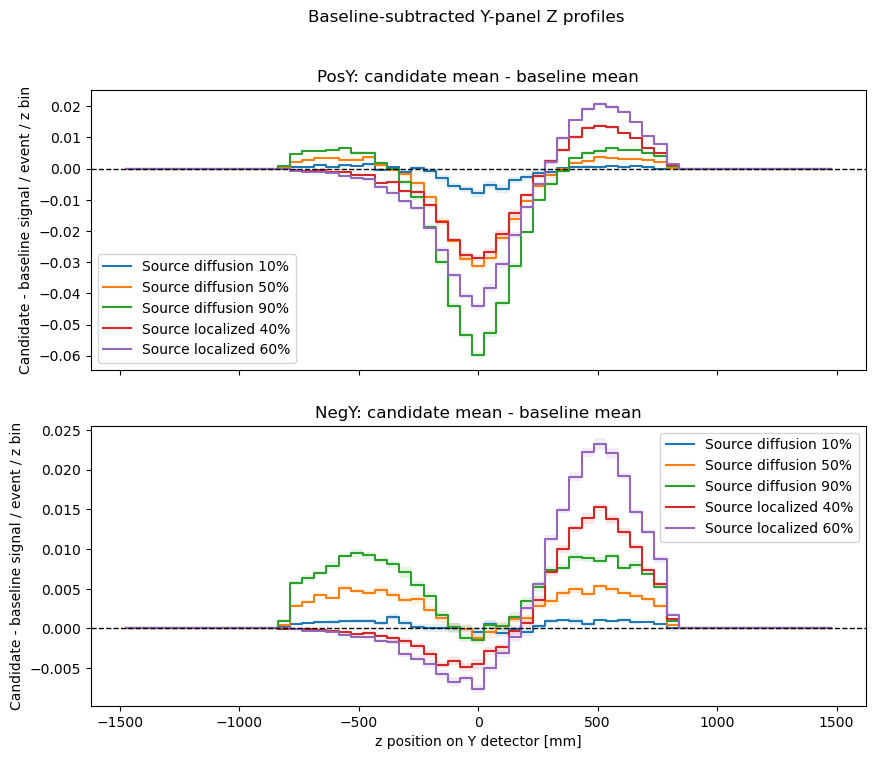

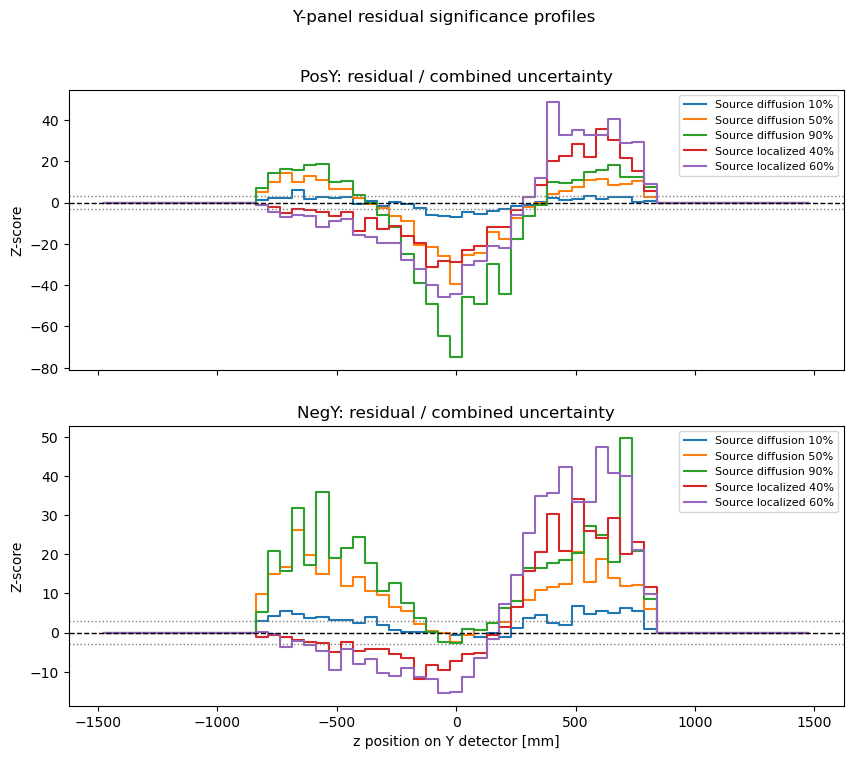

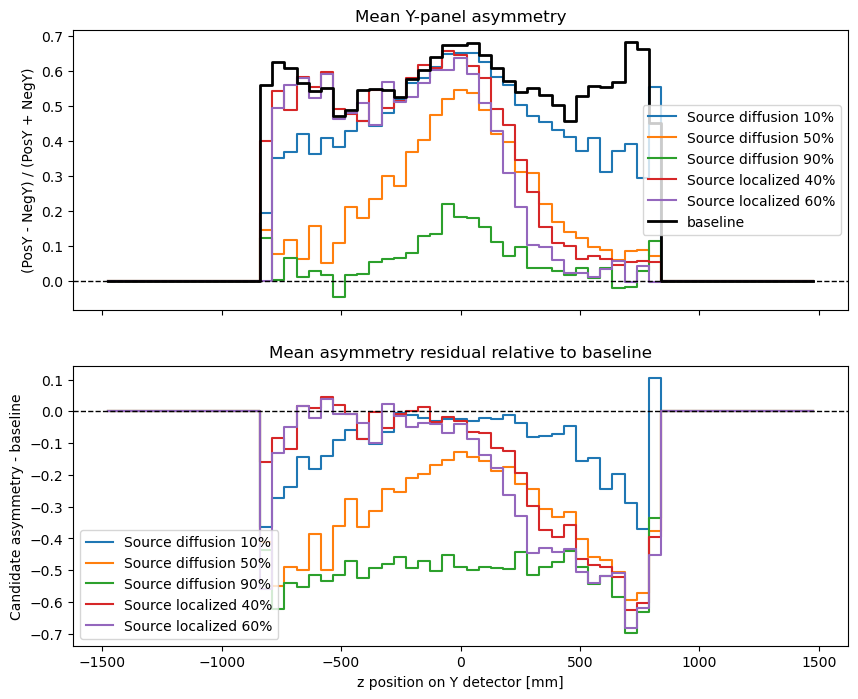

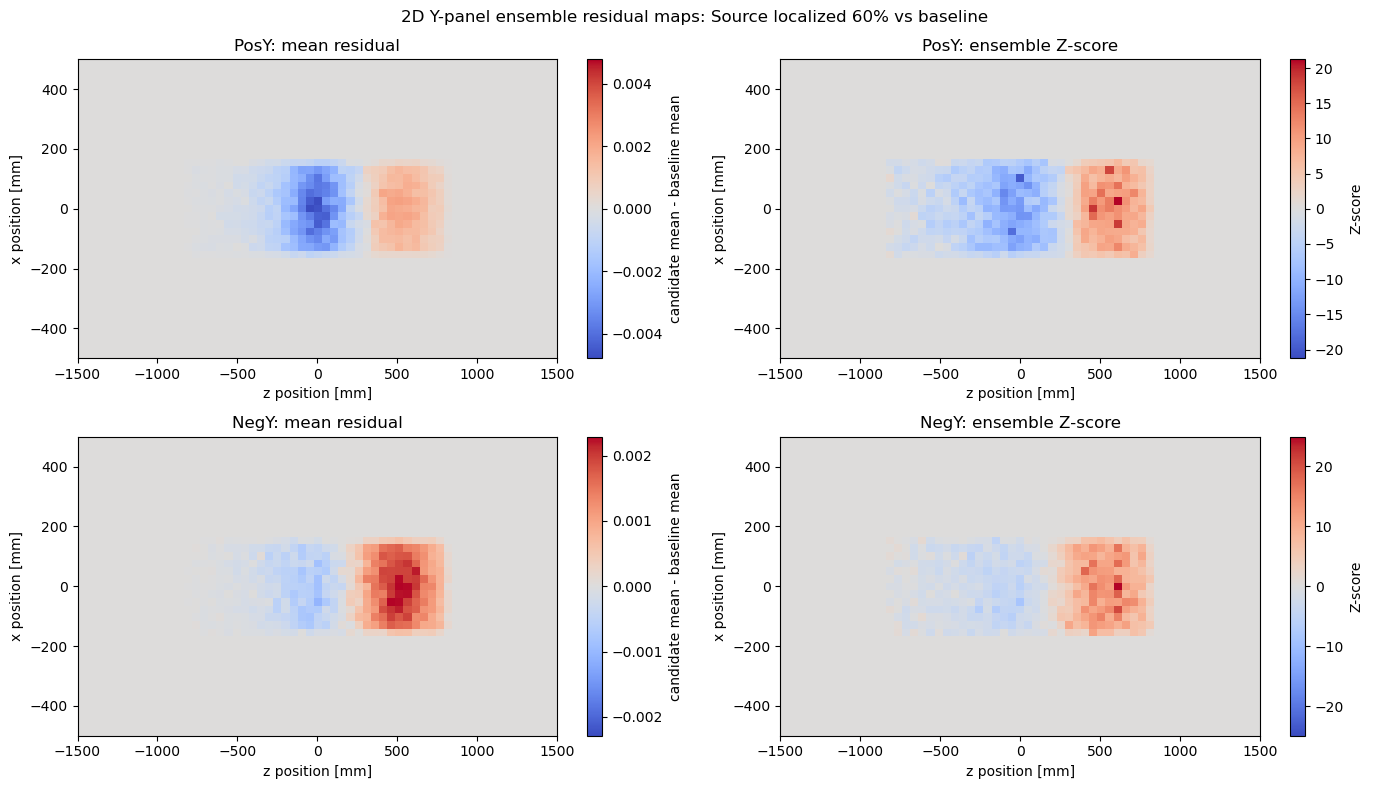

In [ ]:
# Y-panel baseline-subtracted Z profiles and residual maps

z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
heatmap_candidate_key = 'loc60'

summary_rows = []
profile_results = {}
for key in candidate_keys_available:
    profile_results[key] = {}
    for panel in y_panels:
        result = profile_residual(cases, key, [panel], 'z_mm', z_bins)
        profile_results[key][panel] = result
        summary_rows.append({
            'case': key,
            'label': case_labels[key],
            'panel': panel.replace('physPhotonDetector', ''),
            'candidate_reps': len(cases[key]),
            'baseline_reps': len(cases['baseline']),
            'candidate_mean_entries': result['candidate_counts'].sum(axis=1).mean(),
            'baseline_mean_entries': result['baseline_counts'].sum(axis=1).mean(),
            'max_abs_residual': float(np.max(np.abs(result['residual']))) if len(result['residual']) else np.nan,
            'max_abs_zscore': float(np.max(np.abs(result['zscore']))) if len(result['zscore']) else np.nan,
            'strongest_z_mm': z_centers[np.nanargmax(np.abs(result['zscore']))] if len(result['zscore']) else np.nan,
            'max_positive_zscore': float(np.max(result['zscore'])) if len(result['zscore']) else np.nan,
            'min_negative_zscore': float(np.min(result['zscore'])) if len(result['zscore']) else np.nan,
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

if candidate_keys_available:
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for ax, panel in zip(axes, y_panels):
        for key in candidate_keys_available:
            result = profile_results[key][panel]
            residual = result['residual']
            sigma = result['sigma']
            ax.step(z_centers, residual, where='mid', label=case_labels[key])
            ax.fill_between(z_centers, residual - sigma, residual + sigma, step='mid', alpha=0.12)
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f"{panel.replace('physPhotonDetector', '')}: candidate mean - baseline mean")
        ax.set_ylabel('(Candidate - baseline) / event / z bin', fontsize=10)
        ax.legend(fontsize=10)
    axes[-1].set_xlabel('z position on Y detector [mm]')
    fig.suptitle('Baseline-subtracted Y-panel Z profiles', y=0.98)
    plt.show()

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for ax, panel in zip(axes, y_panels):
        for key in candidate_keys_available:
            ax.step(z_centers, profile_results[key][panel]['zscore'], where='mid', label=case_labels[key])
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.axhline(3, color='grey', linestyle=':', linewidth=1)
        ax.axhline(-3, color='grey', linestyle=':', linewidth=1)
        ax.set_title(f"{panel.replace('physPhotonDetector', '')}: residual / combined uncertainty")
        ax.set_ylabel('Z-score')
        ax.legend(fontsize=8)
    axes[-1].set_xlabel('z position on Y detector [mm]')
    fig.suptitle('Y-panel residual significance profiles', y=0.98)
    plt.show()

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    base_pos_counts = stack_profile_counts(cases['baseline'], ['physPhotonDetectorPosY'], 'z_mm', z_bins)
    base_neg_counts = stack_profile_counts(cases['baseline'], ['physPhotonDetectorNegY'], 'z_mm', z_bins)
    base_asym_mean = np.vstack([asymmetry(p, n) for p, n in zip(base_pos_counts, base_neg_counts)]).mean(axis=0)
    for key in candidate_keys_available:
        pos_counts = stack_profile_counts(cases[key], ['physPhotonDetectorPosY'], 'z_mm', z_bins)
        neg_counts = stack_profile_counts(cases[key], ['physPhotonDetectorNegY'], 'z_mm', z_bins)
        cand_asym_mean = np.vstack([asymmetry(p, n) for p, n in zip(pos_counts, neg_counts)]).mean(axis=0)
        axes[0].step(z_centers, cand_asym_mean, where='mid', label=case_labels[key])
        axes[1].step(z_centers, cand_asym_mean - base_asym_mean, where='mid', label=case_labels[key])
    axes[0].step(z_centers, base_asym_mean, where='mid', color='black', linewidth=2, label='baseline')
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_ylabel('(PosY - NegY) / (PosY + NegY)')
    axes[1].set_ylabel('Candidate asymmetry - baseline')
    axes[1].set_xlabel('z position on Y detector [mm]')
    axes[0].set_title('Mean Y-panel asymmetry')
    axes[1].set_title('Mean asymmetry residual relative to baseline')
    axes[0].legend(fontsize=10)
    axes[1].legend(fontsize=10)
    plt.show()

if heatmap_candidate_key in candidate_keys_available:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for row, panel in enumerate(y_panels):
        residual_2d, zscore_2d, _, z_edges, x_edges = map_residual(cases, heatmap_candidate_key, [panel], 'z_mm', 'x_mm', z_bins, x_bins)
        im0 = axes[row, 0].imshow(residual_2d.T, extent=[z_edges[0], z_edges[-1], x_edges[0], x_edges[-1]], origin='lower', aspect='auto', cmap='coolwarm', norm=two_slope_norm(residual_2d))
        axes[row, 0].set_title(f"{panel.replace('physPhotonDetector', '')}: mean residual")
        axes[row, 0].set_ylabel('x position [mm]')
        axes[row, 0].set_xlabel('z position [mm]')
        fig.colorbar(im0, ax=axes[row, 0], label='candidate mean - baseline mean')

        im1 = axes[row, 1].imshow(zscore_2d.T, extent=[z_edges[0], z_edges[-1], x_edges[0], x_edges[-1]], origin='lower', aspect='auto', cmap='coolwarm', norm=two_slope_norm(zscore_2d))
        axes[row, 1].set_title(f"{panel.replace('physPhotonDetector', '')}: ensemble Z-score")
        axes[row, 1].set_ylabel('x position [mm]')
        axes[row, 1].set_xlabel('z position [mm]')
        fig.colorbar(im1, ax=axes[row, 1], label='Z-score')

    fig.suptitle(f"2D Y-panel ensemble residual maps: {case_labels[heatmap_candidate_key]} vs baseline", y=0.98)
    plt.tight_layout()
    plt.show()


## X-panel Z-profile and Y-Z depth maps

This section uses entries into the X detector panels. The 1D diagnostic profile is `z_mm`, while the 2D maps retain `y_mm` versus `z_mm` to inspect depth structure.


,case,label,candidate_reps,baseline_reps,max_abs_profile_z,strongest_profile_z_mm,positive_residual_centroid_z_mm
0,diff10,Source diffusion 10%,10,10,7.148087,-677.966102,-18.951531
1,diff50,Source diffusion 50%,10,10,21.610125,759.322034,-4.671213
2,diff90,Source diffusion 90%,10,10,36.731286,-623.728814,-6.244165
3,loc40,Source localized 40%,10,10,39.319136,515.254237,525.855960
4,loc60,Source localized 60%,10,10,54.176332,650.847458,528.382044


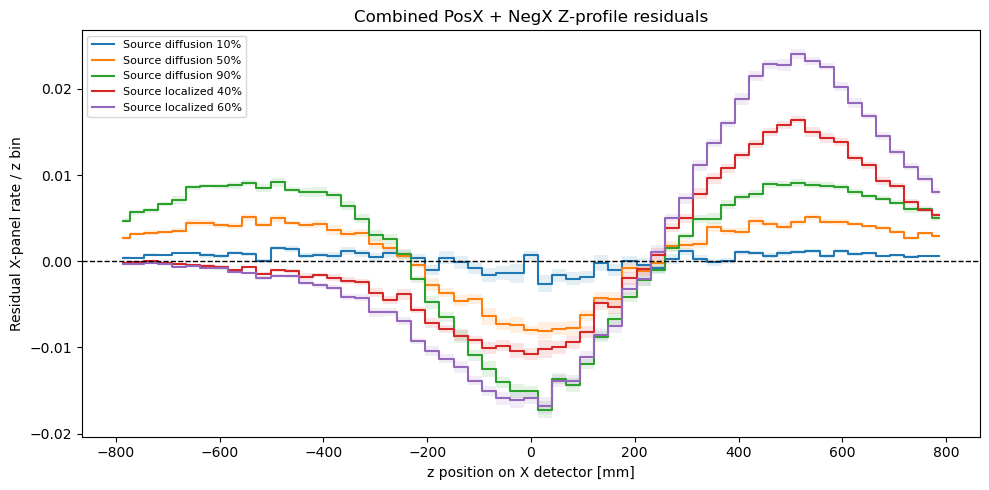

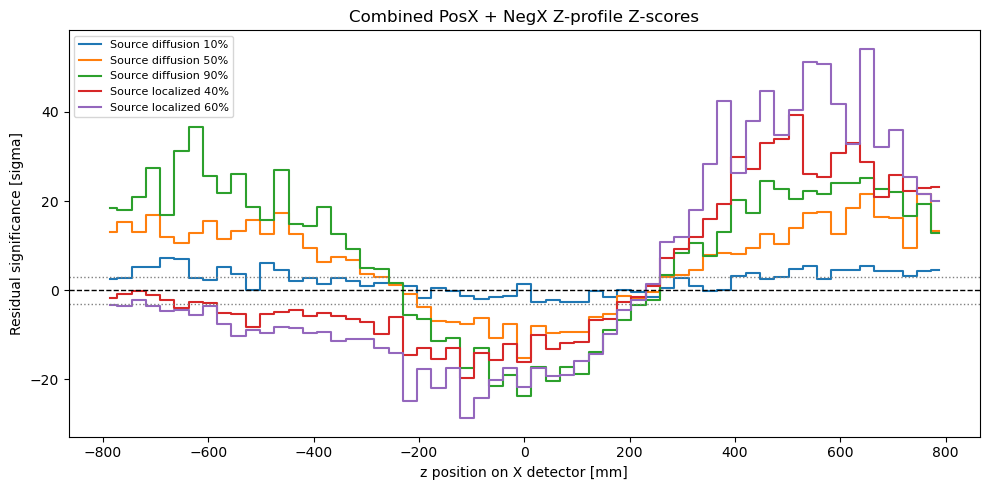

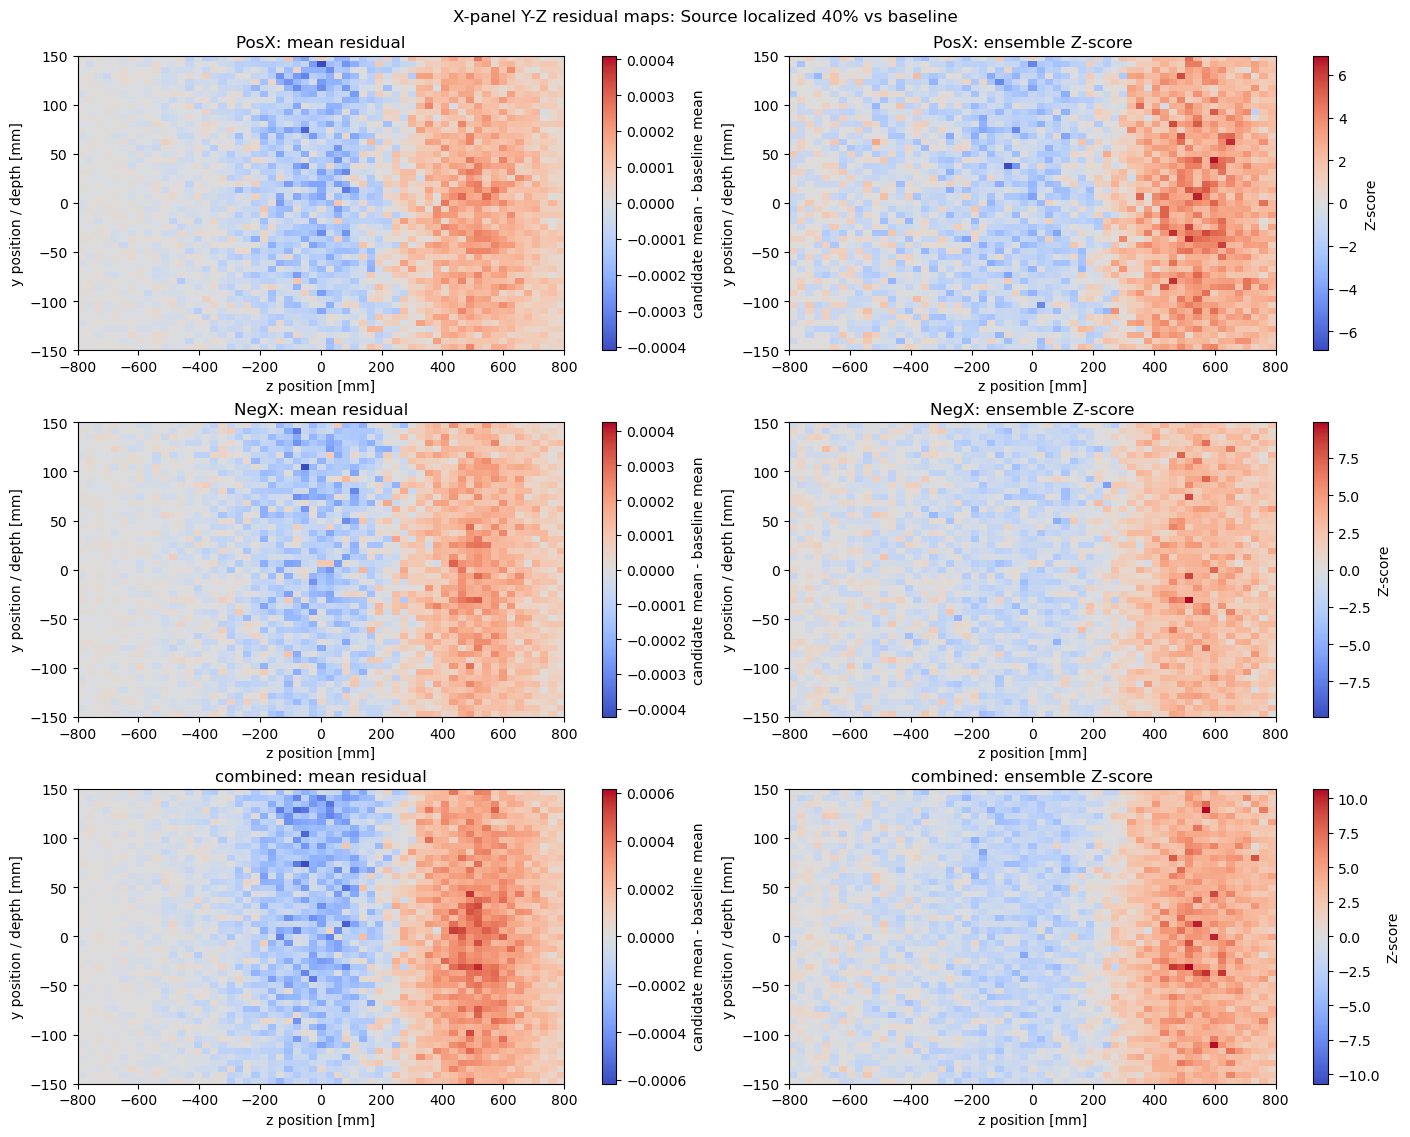

In [4]:
# X-panel baseline-subtracted Z profiles and Y-Z residual maps

x_profile_bins = depth_z_bins
x_profile_centers = 0.5 * (x_profile_bins[:-1] + x_profile_bins[1:])
x_panel_heatmap_priority = ['loc40', 'loc60', 'diff50', 'diff90', 'diff10']

x_profile_results = {}
x_summary_rows = []
for key in candidate_keys_available:
    result = profile_residual(cases, key, x_panels, 'z_mm', x_profile_bins)
    x_profile_results[key] = result
    x_summary_rows.append({
        'case': key,
        'label': case_labels[key],
        'candidate_reps': len(cases[key]),
        'baseline_reps': len(cases['baseline']),
        'max_abs_profile_z': np.nanmax(np.abs(result['zscore'])) if result['zscore'].size else np.nan,
        'strongest_profile_z_mm': x_profile_centers[np.nanargmax(np.abs(result['zscore']))] if result['zscore'].size else np.nan,
        'positive_residual_centroid_z_mm': positive_weighted_position(x_profile_centers, result['residual']),
    })

x_depth_summary_df = pd.DataFrame(x_summary_rows)
display(x_depth_summary_df)

if candidate_keys_available:
    fig, ax = plt.subplots(figsize=(10, 5))
    for key in candidate_keys_available:
        result = x_profile_results[key]
        ax.step(x_profile_centers, result['residual'], where='mid', label=case_labels[key])
        ax.fill_between(x_profile_centers, result['residual'] - result['sigma'], result['residual'] + result['sigma'], step='mid', alpha=0.12)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('Residual X-panel rate / z bin')
    ax.set_xlabel('z position on X detector [mm]')
    ax.set_title('Combined PosX + NegX Z-profile residuals')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    for key in candidate_keys_available:
        result = x_profile_results[key]
        ax.step(x_profile_centers, result['zscore'], where='mid', label=case_labels[key])
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axhline(3, color='grey', linestyle=':', linewidth=1)
    ax.axhline(-3, color='grey', linestyle=':', linewidth=1)
    ax.set_ylabel('Residual significance [sigma]')
    ax.set_xlabel('z position on X detector [mm]')
    ax.set_title('Combined PosX + NegX Z-profile Z-scores')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    x_heatmap_candidate_key = next((key for key in x_panel_heatmap_priority if key in candidate_keys_available), candidate_keys_available[0])
    panels_for_maps = [(['physPhotonDetectorPosX'], 'PosX'), (['physPhotonDetectorNegX'], 'NegX'), (x_panels, 'combined')]
    fig, axes = plt.subplots(len(panels_for_maps), 2, figsize=(14, 11), constrained_layout=True)
    for row, (panels, panel_label) in enumerate(panels_for_maps):
        residual_2d, zscore_2d, _, z_edges, y_edges = map_residual(cases, x_heatmap_candidate_key, panels, 'z_mm', 'y_mm', depth_z_bins, depth_y_bins)

        im0 = axes[row, 0].imshow(residual_2d.T, extent=[z_edges[0], z_edges[-1], y_edges[0], y_edges[-1]], origin='lower', aspect='auto', cmap='coolwarm', norm=two_slope_norm(residual_2d))
        axes[row, 0].set_title(f'{panel_label}: mean residual')
        axes[row, 0].set_xlabel('z position [mm]')
        axes[row, 0].set_ylabel('y position / depth [mm]')
        fig.colorbar(im0, ax=axes[row, 0], label='candidate mean - baseline mean')

        im1 = axes[row, 1].imshow(zscore_2d.T, extent=[z_edges[0], z_edges[-1], y_edges[0], y_edges[-1]], origin='lower', aspect='auto', cmap='coolwarm', norm=two_slope_norm(zscore_2d))
        axes[row, 1].set_title(f'{panel_label}: ensemble Z-score')
        axes[row, 1].set_xlabel('z position [mm]')
        axes[row, 1].set_ylabel('y position / depth [mm]')
        fig.colorbar(im1, ax=axes[row, 1], label='Z-score')

    fig.suptitle(f"X-panel Y-Z residual maps: {case_labels[x_heatmap_candidate_key]} vs baseline", y=1.02)
    plt.show()


## Cumulative time-window baseline-subtracted profiles

This section applies cumulative cuts `time_s <= T` for `1 h`, `2 h`, `12 h`, `1 d`, `2 d`, `5 d`, and `10 d`. It compares Y-panel and combined X-panel Z profiles against baseline and summarizes significance versus the exact time cuts.


,case,label,view,time_label,time_s,candidate_reps,baseline_reps,max_abs_zscore,max_positive_zscore,min_negative_zscore,strongest_z_mm,total_residual_per_event
0,diff10,Source diffusion 10%,PosY,1 h,3600,10,10,2.522219,1.406224,-2.522219,-203.389831,-0.000321
1,diff10,Source diffusion 10%,PosY,2 h,7200,10,10,2.726211,1.810826,-2.726211,-101.694915,-0.001091
2,diff10,Source diffusion 10%,PosY,12 h,43200,10,10,3.358090,2.084261,-3.358090,-50.847458,-0.002726
3,diff10,Source diffusion 10%,PosY,1 d,86400,10,10,3.641013,3.120774,-3.641013,-50.847458,-0.005413
4,diff10,Source diffusion 10%,PosY,2 d,172800,10,10,4.750804,2.604316,-4.750804,-50.847458,-0.012592
...,...,...,...,...,...,...,...,...,...,...,...,...
100,loc60,Source localized 60%,PosX + NegX,12 h,43200,10,10,23.027574,23.027574,-8.951419,559.322034,0.006277
101,loc60,Source localized 60%,PosX + NegX,1 d,86400,10,10,29.860177,29.860177,-17.090393,559.322034,0.013904
102,loc60,Source localized 60%,PosX + NegX,2 d,172800,10,10,40.522913,40.522913,-18.494462,559.322034,0.025687
103,loc60,Source localized 60%,PosX + NegX,5 d,432000,10,10,53.418884,53.418884,-23.804837,559.322034,0.052386


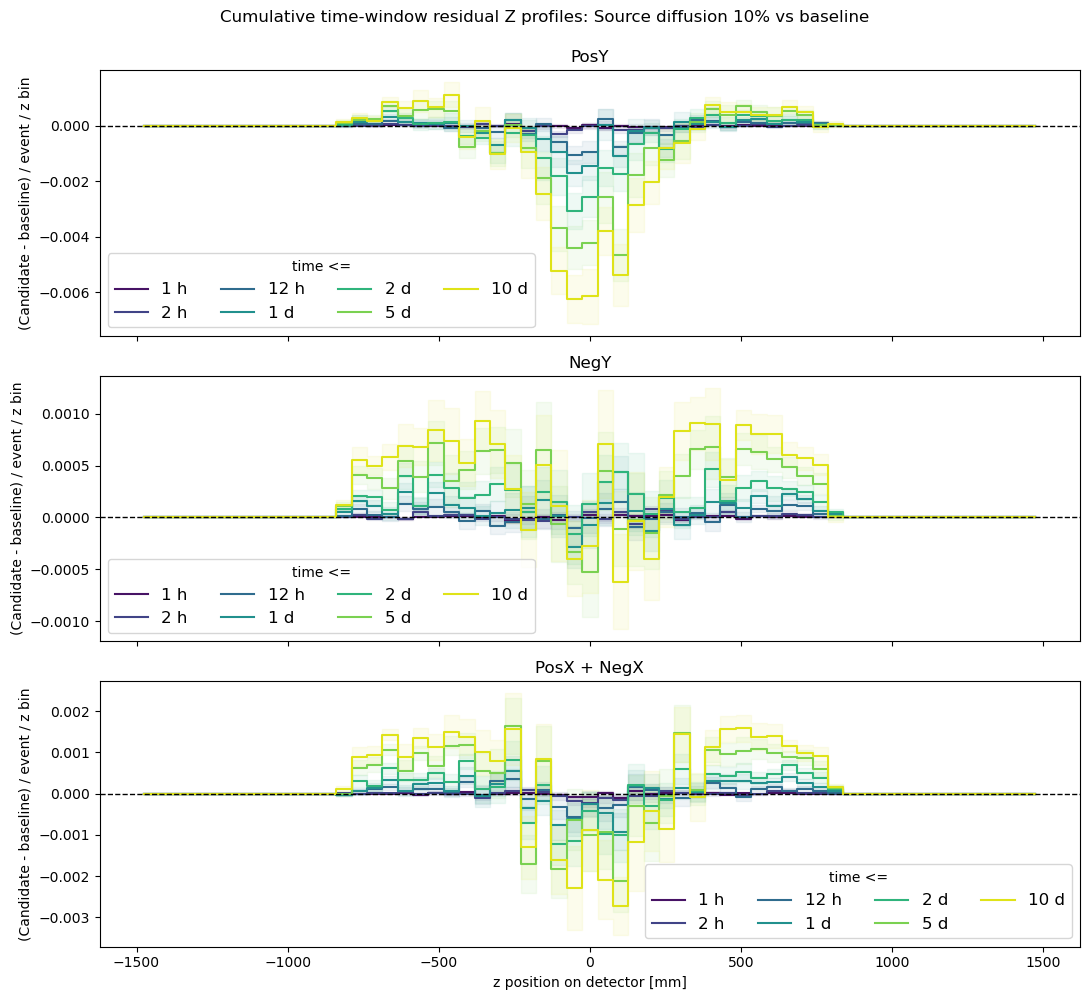

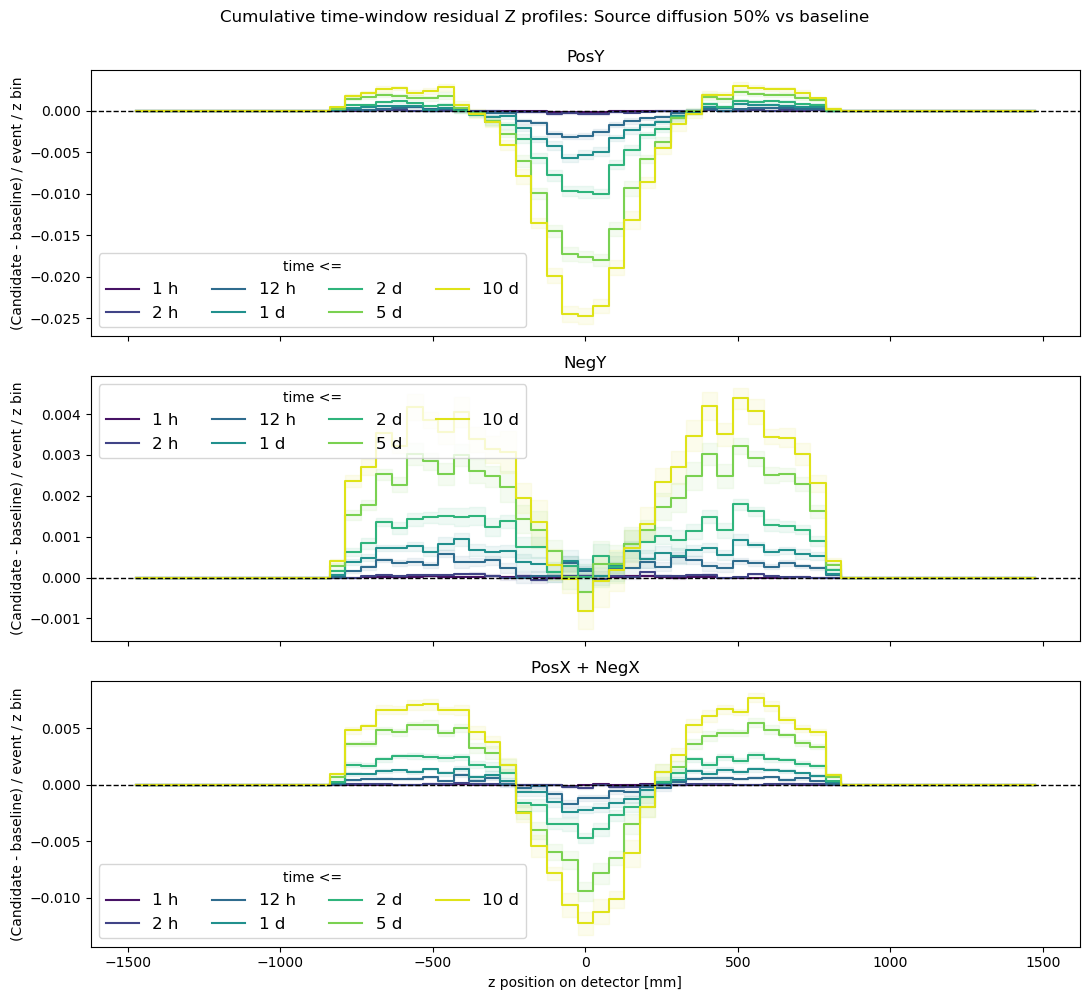

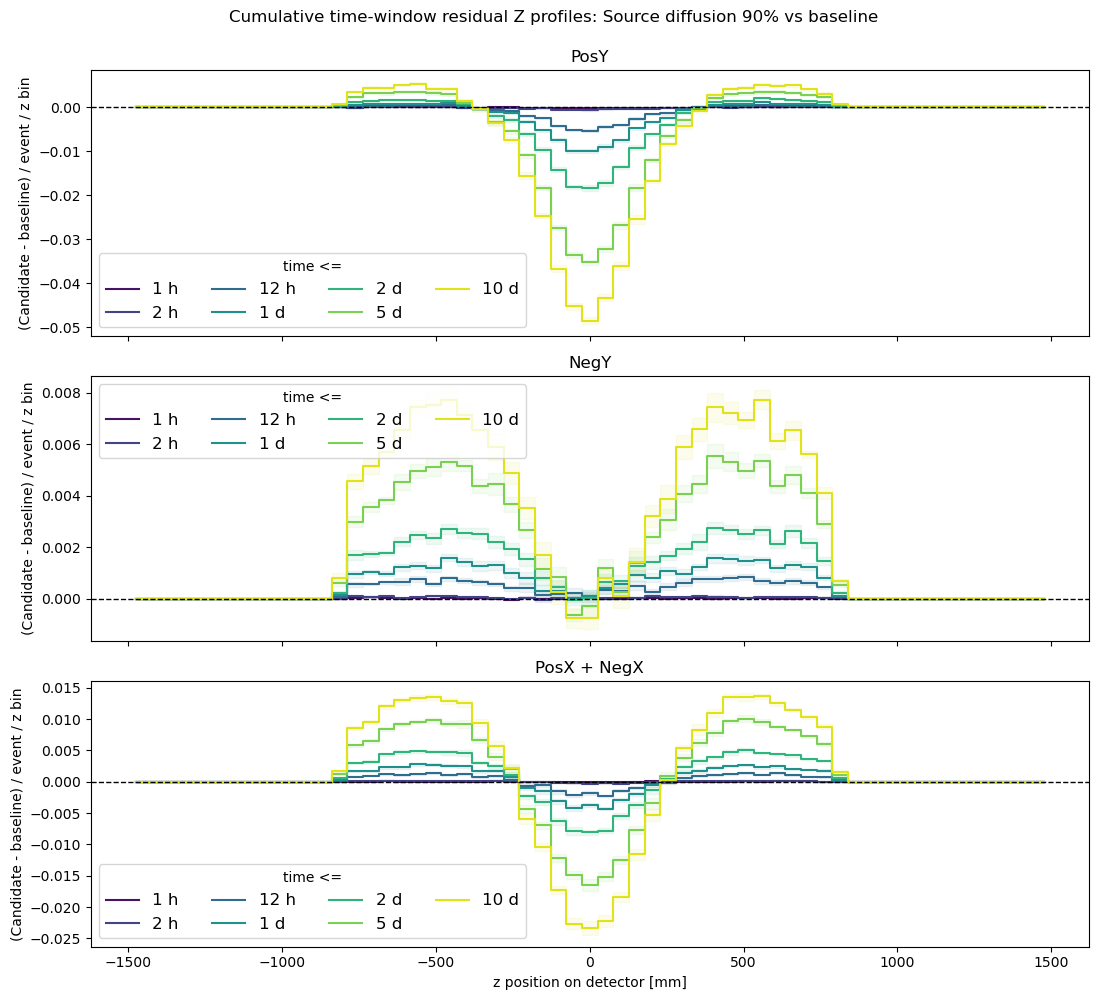

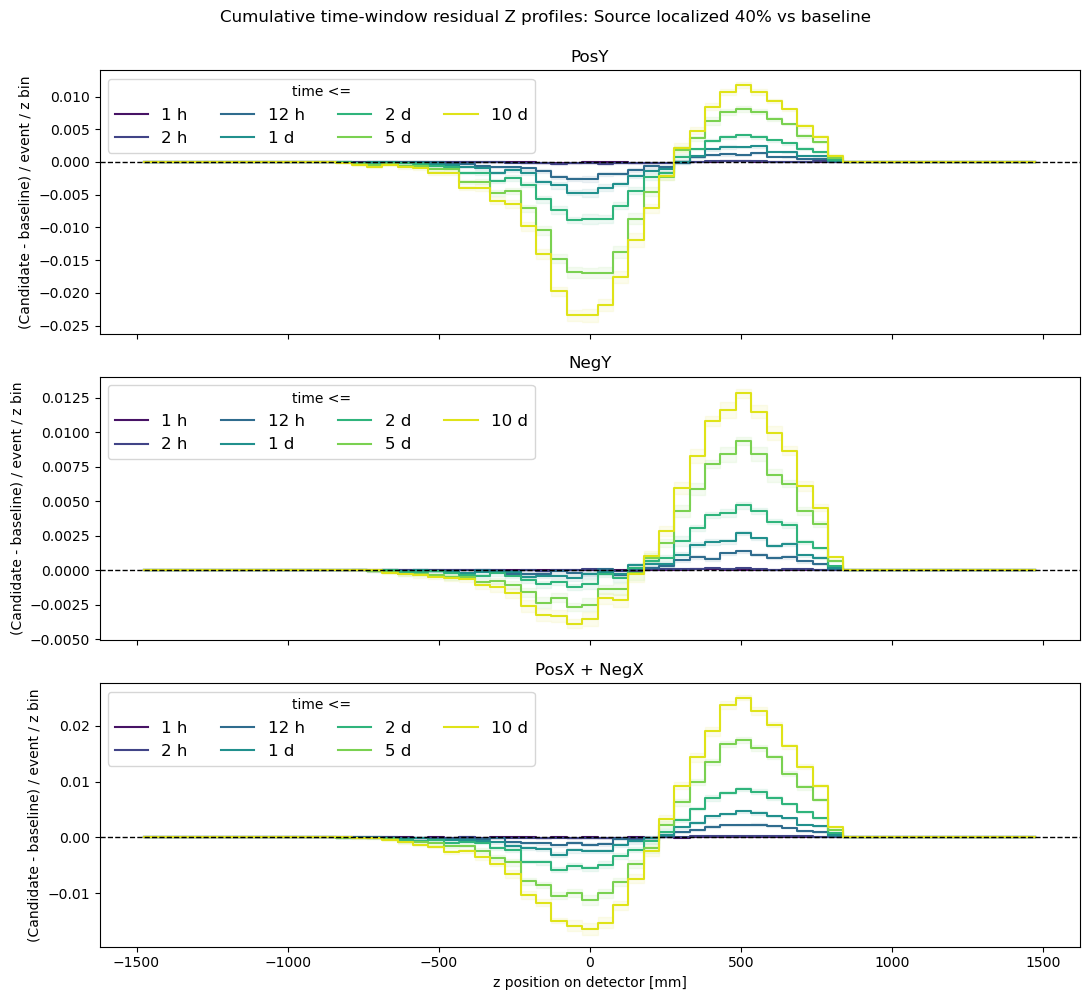

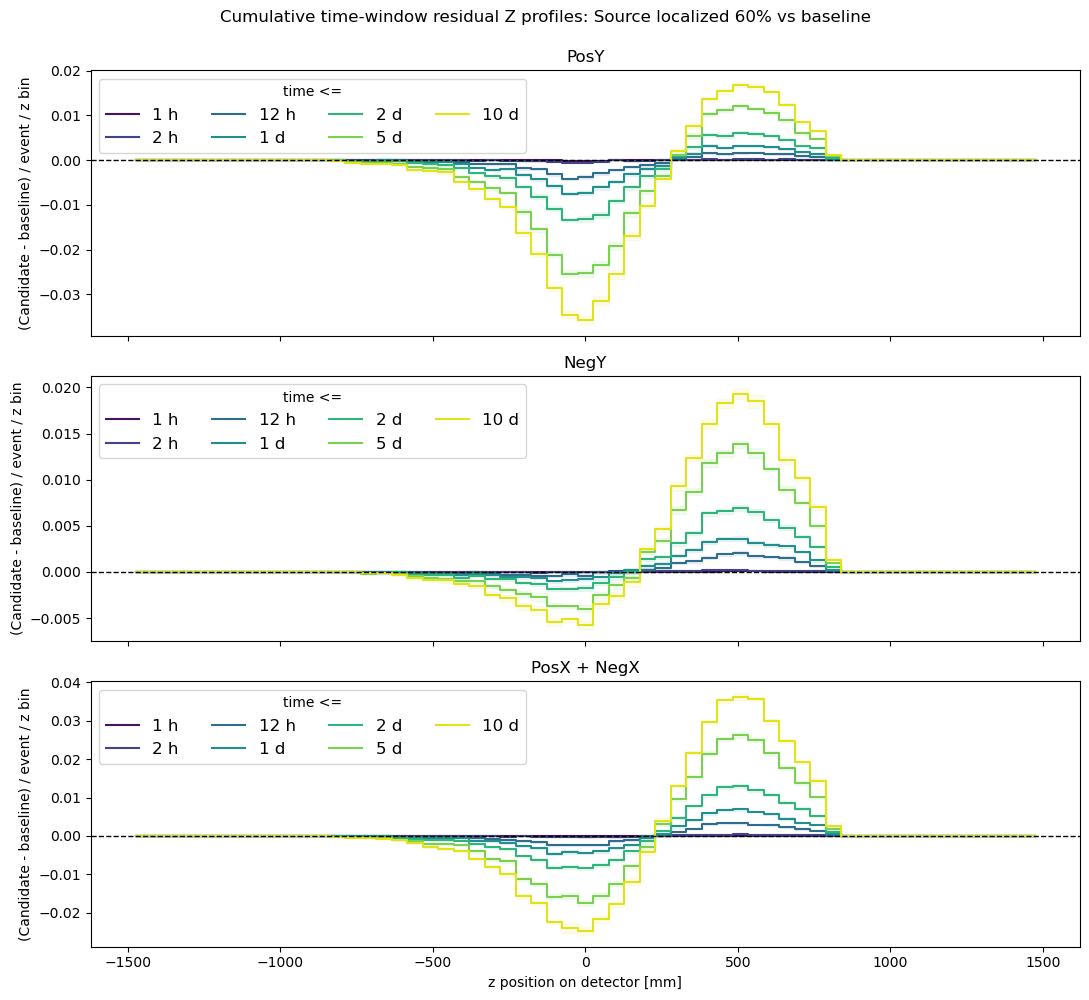

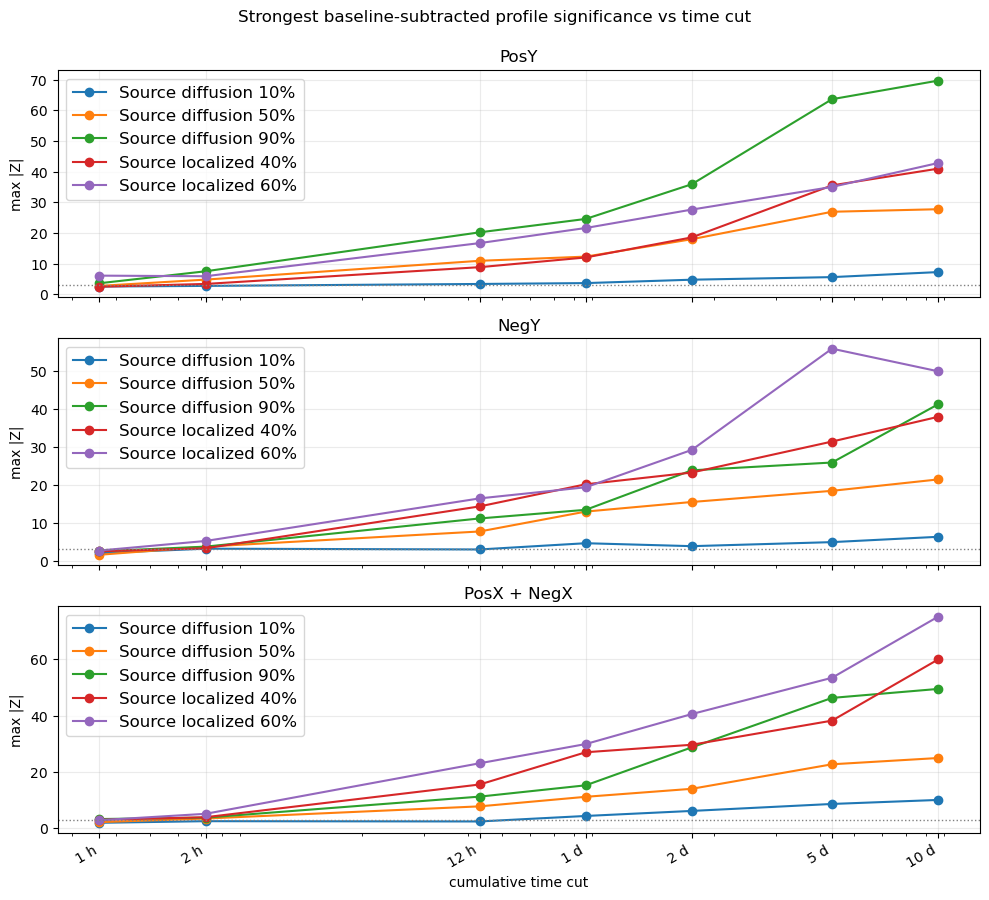

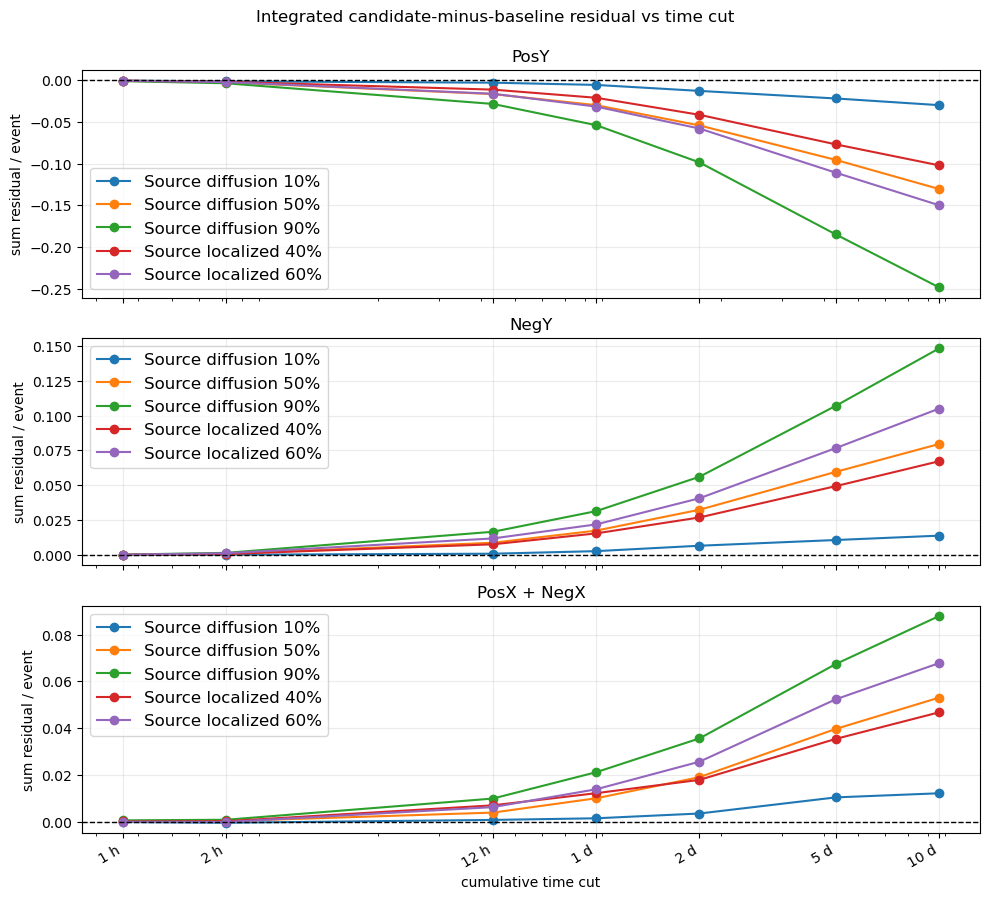

In [5]:
# Time-window baseline-subtracted profiles

time_profile_views = {
    'PosY': ['physPhotonDetectorPosY'],
    'NegY': ['physPhotonDetectorNegY'],
    'PosX + NegX': x_panels,
}

time_profile_results = {}
time_summary_rows = []
for key in candidate_keys_available:
    time_profile_results[key] = {}
    for view_name, panels in time_profile_views.items():
        time_profile_results[key][view_name] = {}
        for time_label, time_limit_s in time_thresholds:
            result = profile_residual(cases, key, panels, 'z_mm', z_bins, time_limit_s=time_limit_s)
            time_profile_results[key][view_name][time_label] = {'time_s': time_limit_s, **result}
            time_summary_rows.append({
                'case': key,
                'label': case_labels[key],
                'view': view_name,
                'time_label': time_label,
                'time_s': time_limit_s,
                'candidate_reps': len(cases[key]),
                'baseline_reps': len(cases['baseline']),
                'max_abs_zscore': np.nanmax(np.abs(result['zscore'])) if result['zscore'].size else np.nan,
                'max_positive_zscore': np.nanmax(result['zscore']) if result['zscore'].size else np.nan,
                'min_negative_zscore': np.nanmin(result['zscore']) if result['zscore'].size else np.nan,
                'strongest_z_mm': z_centers[np.nanargmax(np.abs(result['zscore']))] if result['zscore'].size else np.nan,
                'total_residual_per_event': np.nansum(result['residual']),
            })

time_summary_df = pd.DataFrame(time_summary_rows)
display(time_summary_df)

time_colors = dict(zip([label for label, _ in time_thresholds], plt.cm.viridis(np.linspace(0.05, 0.95, len(time_thresholds)))))
for key in candidate_keys_available:
    fig, axes = plt.subplots(len(time_profile_views), 1, figsize=(11, 10), sharex=True)
    for ax, (view_name, _) in zip(axes, time_profile_views.items()):
        for time_label, _ in time_thresholds:
            result = time_profile_results[key][view_name][time_label]
            residual = result['residual']
            sigma = result['sigma']
            color = time_colors[time_label]
            ax.step(z_centers, residual, where='mid', color=color, label=time_label)
            ax.fill_between(z_centers, residual - sigma, residual + sigma, step='mid', color=color, alpha=0.08)
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(view_name)
        ax.set_ylabel('(Candidate - baseline) / event / z bin')
        ax.legend(title='time <=', fontsize=12, ncols=4)
    axes[-1].set_xlabel('z position on detector [mm]')
    fig.suptitle(f'Cumulative time-window residual Z profiles: {case_labels[key]} vs baseline', y=0.995)
    plt.tight_layout()
    plt.show()

if not time_summary_df.empty:
    fig, axes = plt.subplots(len(time_profile_views), 1, figsize=(10, 9), sharex=True)
    for ax, view_name in zip(axes, time_profile_views):
        view_df = time_summary_df[time_summary_df['view'] == view_name]
        for key in candidate_keys_available:
            case_df = view_df[view_df['case'] == key].sort_values('time_s')
            ax.plot(case_df['time_s'], case_df['max_abs_zscore'], marker='o', label=case_labels[key])
        ax.axhline(3, color='grey', linestyle=':', linewidth=1)
        set_exact_time_ticks(ax)
        ax.set_ylabel('max |Z|')
        ax.set_title(view_name)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=12)
    axes[-1].set_xlabel('cumulative time cut')
    fig.suptitle('Strongest baseline-subtracted profile significance vs time cut', y=0.995)
    plt.tight_layout()
    plt.show()

if not time_summary_df.empty:
    fig, axes = plt.subplots(len(time_profile_views), 1, figsize=(10, 9), sharex=True)
    for ax, view_name in zip(axes, time_profile_views):
        view_df = time_summary_df[time_summary_df['view'] == view_name]
        for key in candidate_keys_available:
            case_df = view_df[view_df['case'] == key].sort_values('time_s')
            ax.plot(case_df['time_s'], case_df['total_residual_per_event'], marker='o', label=case_labels[key])
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        set_exact_time_ticks(ax)
        ax.set_ylabel('sum residual / event')
        ax.set_title(view_name)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=12)
    axes[-1].set_xlabel('cumulative time cut')
    fig.suptitle('Integrated candidate-minus-baseline residual vs time cut', y=0.995)
    plt.tight_layout()
    plt.show()
